# ¡Hola Diego! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


-----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Diego, realizaste un trabajo muy sólido desde el inicio, con una limpieza de datos adecuada, análisis coherentes y visualizaciones bien enfocadas que permiten entender el comportamiento de la industria del videojuego en distintos contextos. También mostraste una buena interpretación de los resultados y una capacidad destacada para relacionar los hallazgos con aspectos culturales y del mercado. 

Como puntos a mejorar, podrías optimizar algunos cálculos y enriquecer ciertos gráficos para facilitar la lectura comparativa, además de considerar pequeños ajustes en el manejo de valores faltantes para mantener la consistencia estadística. 

En general, desarrollaste un muy buen análisis en este caso de estudio, sigue manteniendo esta combinación de habilidades técnicas, analíticas y estratégicas en tus futuros proyectos.

¡Te deseo muchos éxitos en tu próximo Sprint! 🚀

*Estado del Proyecto:* **Aprobado**



</div>

-----

# Paso 1. Abre el archivo de datos y estudia la información general

In [1]:
# Se cargan todas las librerías necesarias para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

## 1.1 Cargar Datos

In [2]:
# Se carga el archivo de datos en un DataFrame
df_games = pd.read_csv("/datasets/games.csv")

## 1.2 Vista Rapida de los Datos

In [3]:
# Se imprime la información general/resumida sobre el DataFrame df_games
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Se imprime una muestra de los datos del DataFrame
print(df_games.head())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [5]:
# Se visualiza una descripción estadistica general de los datos
df_games.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [6]:
# Se verifica si existen renglones duplicados
df_games[df_games.duplicated()]

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating


In [7]:
# Se realiza el conteo de todos los valores nulos por columna
print("Valores faltantes por columna:")
print(df_games.isnull().sum())


Valores faltantes por columna:
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64


## Conclusiones Parte 1:
- Existen 16715 renglones y 11 columnas en total.
- La columna Year_of_Release está como flotante y tiene que se entero.
- La columna User_Score es de tipo object y deberia ser flotante
- No hay registros o renglones duplicados.
- Las columnas Critic_Score, User_Score y Rating tienen demasiados datos ausentes (NaN).

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo importando las librerías y los datos del proyecto. Adicionalmente usaste correctamente las funciones `info`, `describe` y `head`, esto te permite hacer una primera revisión de los datos, su estructura y contenido. 


Además hiciste un buen trabajo comprobando la presencia de datos duplicados y faltantes, esto es clave para verificar la integridad del dataset y evitar sesgos o errores al momento de analizar los datos

</div>

# Paso 2. Prepara los datos

## 2.1 Reemplaza los nombres de las columnas (ponlos en minúsculas).

In [8]:

# Cambiamos a minúsculas todas las columnas de DataFrame
df_games.columns = df_games.columns.str.lower()

# Comprobamos el cambio
print(df_games.head())


                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score user_score rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


## 2.2 Convierte los datos en los tipos necesarios.

### 2.2.1 Primero se convierte la columna year_of_release de flotante a entero

In [9]:
# Primero de reemplazan los datos faltantes NaN por 0s para que no marque error el cambio de tipo de dato.
# Despues ya se cambia el tipo de dato
df_games['year_of_release'] = df_games['year_of_release'].fillna(0).astype(int)

# Se verifica el cambio
df_games.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.4+ MB


### 2.2.2 Despues se convierte la columna user_score de object a flotante

In [10]:
# Primero se visualizan los datos unicos de la columna user_score 
print(df_games['user_score'].unique())

# Como se encontraron datos 'tbd' se reemplazan por NaN
df_games['user_score'] = df_games['user_score'].replace('tbd', np.nan)

# Por ultimo ya se puede hacer el cambio del tipo object a tipo float
df_games['user_score'] = df_games['user_score'].astype(float)

# Se verifica el cambio
df_games.info()

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Has desarrollado adecuadamente una serie de pasos para preparar los datos antes del análisis: estandarizaste los nombres de las columnas, reemplazaste valores faltantes en `year_of_release` para permitir el cambio de tipo de dato y gestionaste correctamente los valores no numéricos en `user_score` antes de convertirla a tipo `float`. Esta secuencia muestra un buen manejo de la limpieza de datos. 

Una sugerencia sería acompañar el uso de `fillna(0)` con una nota sobre el impacto de reemplazar años faltantes por cero, ya que podría no ser informativamente útil para ciertos análisis.


</div>

## 2.3 Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [11]:

# Se agrega la nueva columna "total_sales"
df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']

# Se visualiza la nueva columna
print(df_games.head())


                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
4      8.89     10.22         1.00           NaN         NaN    NaN   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4

## Conclusiones Parte 2:
- Antes de cambiar la columna year_of_release de flotante a entero primero fue necesario reemplazar los datos faltantes NaN por 0s para que no marque error
- Se encontró que la columna user_score tenía datos 'tbd' no se podia cambiar el tipo de dato por lo mismo, primero se tuvo que reemplazar el 'tbd' por NaN y despues ya cambiar el tipo de dato de object a flotante
- En la columna user_score se dejaron los datos NaN porque si se reemplazan por 0s quiere decir un Score de 0 y eso afectaria mucho al análisis, se optó por dejarlos en NaN por ahora
- Al crear la nueca columna total_sales tenemos detos mas contundentes sobre la venta de cada juego, con ese dato podemos hacer cálculso mas precismos mas adelante

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo obteniendo las ventas totales. Si quieres optimizar la suma puedes hacerlo así:

```python
df['total_sales'] = df[['na_sales','eu_sales','jp_sales','other_sales']].sum(axis=1)

```

</div>

# Paso 3. Analiza los datos

## 3.1 Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

Juegos lanzados por año:
Año      Total
0        269
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64


count      38.000000
mean      439.868421
std       446.322037
min         9.000000
25%        37.250000
50%       313.500000
75%       734.750000
max      1427.000000
Name: year_of_release, dtype: float64


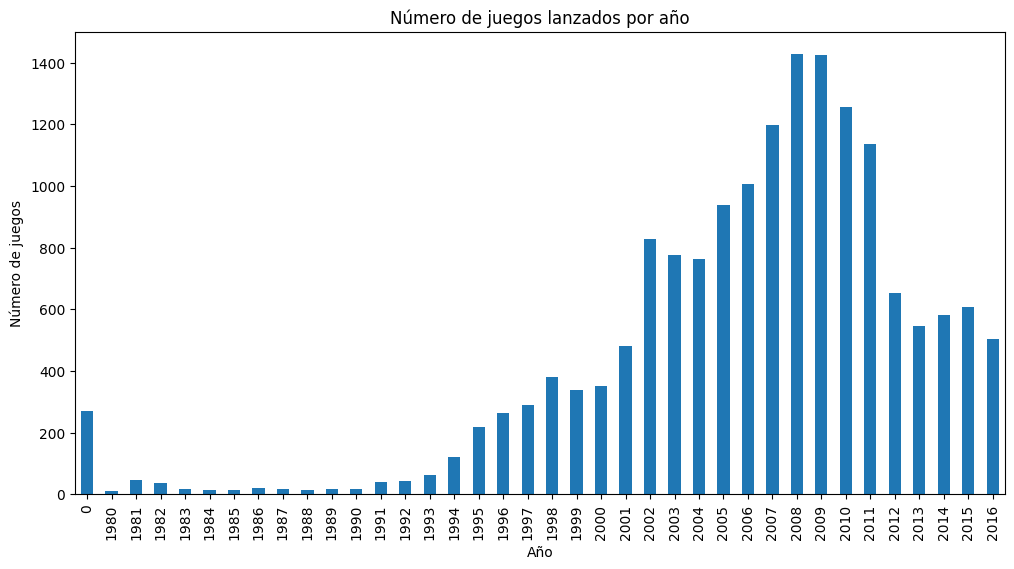

In [12]:
# Se analiza la distribución de juegos por año
games_per_year = df_games['year_of_release'].value_counts().sort_index()
print("Juegos lanzados por año:")
print("Año      Total")
print(games_per_year)
print()
print()

# Se analiza estadisticamente los juegos por año
print(games_per_year.describe())

# Se crea un gráfico de la distribución para mejor análisis
plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar')
plt.title('Número de juegos lanzados por año')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.show()


### Conclusiones 3.1
- Hay 269 juegos del año 0, esto quiere decir que no hay registro de esas fechas de lanzamiento, por lo tanto se descartan para analisis de fechas.
- La gráfica de barras esta cargada a la derecha, quiere decir que la moda de los videojuegos empezó desde los 90s.
- El boom de la creación de juegos fue en el 2008 y 2009

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Muy buen trabajo! La gráfica muestra un crecimiento hasta 2008-2009, seguido de una caída en lanzamientos. Esto podría deberse al éxito de consolas como PS3 y Xbox 360, y luego a cambios en la industria: más enfoque en calidad, auge de juegos móviles, distribución digital o la crisis de 2008.

</div>

## 3.2 Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

Plataformas ordenadas por ventas totales:
   platform  total_sales
0       PS2      1255.77
1      X360       971.42
2       PS3       939.65
3       Wii       907.51
4        DS       806.12
5        PS       730.86
6       GBA       317.85
7       PS4       314.14
8       PSP       294.05
9        PC       259.52
10      3DS       259.00
11       XB       257.74
12       GB       255.46
13      NES       251.05
14      N64       218.68
15     SNES       200.04
16       GC       198.93
17     XOne       159.32
18     2600        96.98
19     WiiU        82.19
20      PSV        54.07
21      SAT        33.59
22      GEN        30.77
23       DC        15.95
24      SCD         1.86
25       NG         1.44
26       WS         1.42
27     TG16         0.16
28      3DO         0.10
29       GG         0.04
30     PCFX         0.03

Lista de top 10 plataformas:   platform  total_sales
0      PS2      1255.77
1     X360       971.42
2      PS3       939.65
3      Wii       907.51
4       

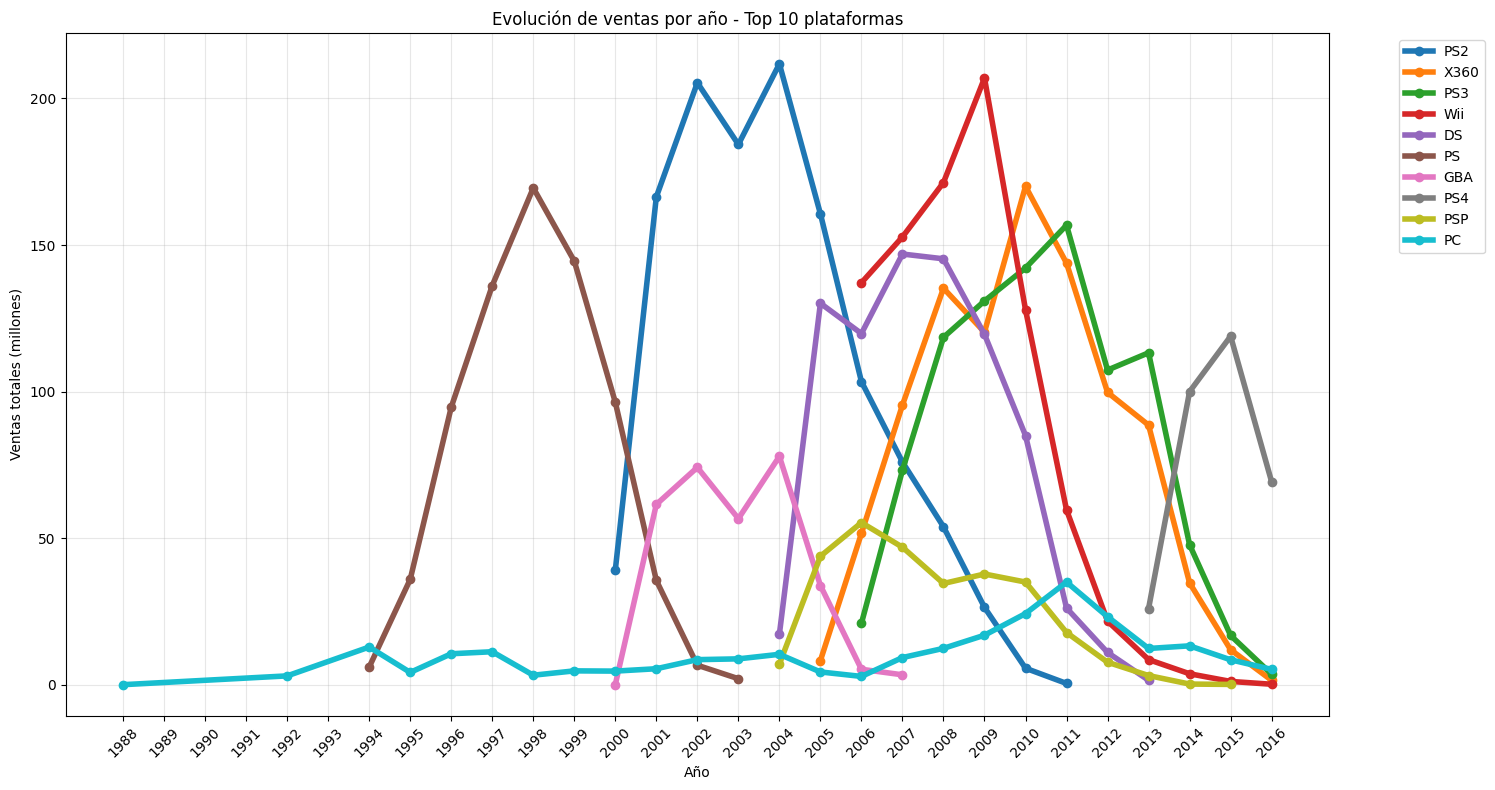

Ciclo de vida de las top 10 plataformas:
  platform  first_year  last_year  lifecycle_years
2       PC        1988       2016               29
3       PS        1994       2003               10
1      GBA        2000       2007                8
4      PS2        2000       2011               12
0       DS        2004       2013               10
7      PSP        2004       2015               12
9     X360        2005       2016               12
5      PS3        2006       2016               11
8      Wii        2006       2016               11
6      PS4        2013       2016                4
Estadísticas de duración de consolas (excluyendo PC y el PS4):
Promedio: 10.8 años
Mediana: 11.0 años
Rango: 8-12 años


In [13]:
# Se agrupa por Plataforma y el total de ventas
sales_per_platform = df_games.groupby(["platform"])["total_sales"].sum().reset_index()

# Se ordena por ventas totales (de mayor a menor)
sales_per_platform_sorted = sales_per_platform.sort_values('total_sales', ascending=False).reset_index(drop=True)

# Se muestra la tabla agrupada y ordenada
print("Plataformas ordenadas por ventas totales:")
print(sales_per_platform_sorted)
print()

# Se crea una lista con los nombres de las top 10 plataformas
top_10_platforms_list = sales_per_platform_sorted.head(10)
print("Lista de top 10 plataformas:", top_10_platforms_list)

# Filtrar datos del DataFrame df_games solo para las top 10 plataformas
df_top_platforms = df_games[df_games['platform'].isin(top_10_platforms_list['platform'])]

# Se crea la distribución por año para cada plataforma
platform_year_sales = df_top_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
print("Ventas por año y plataforma (primeras 20 filas):")
print(platform_year_sales.head(20))

##########################################################################
## Se crea un gráfico de líneas para ver mejor la evolución temporal
plt.figure(figsize=(15, 8))

# Se filtrar datos sin año 0 para mejor visualización (Tambien se encontró que se vendió el DS en 1985)
# Pero seguro fue una captura incorrecta ya que el Nintendo DS salió a la venta en el 2004
platform_year_sales_clean = platform_year_sales[platform_year_sales['year_of_release'] > 1985]

for platform in top_10_platforms_list['platform']:
    platform_data = platform_year_sales_clean[platform_year_sales_clean['platform'] == platform]
    plt.plot(platform_data['year_of_release'], platform_data['total_sales'], 
             marker='o', label=platform, linewidth=4)

plt.title('Evolución de ventas por año - Top 10 plataformas')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones)')

# Para que se muestren todos los años en el eje x
min_year = platform_year_sales_clean['year_of_release'].min()
max_year = platform_year_sales_clean['year_of_release'].max()
plt.xticks(range(int(min_year), int(max_year) + 1), rotation=45)

# Configuraciones de la gráfica
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

########################################################################

# Se analizan ciclos de vida de las top 10 plataformas
platform_lifecycle = platform_year_sales_clean.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
platform_lifecycle.columns = ['platform', 'first_year', 'last_year']
platform_lifecycle['lifecycle_years'] = platform_lifecycle['last_year'] - platform_lifecycle['first_year'] + 1

print("Ciclo de vida de las top 10 plataformas:")
print(platform_lifecycle.sort_values('first_year'))

# Para hacer el análisis estadistico se quita PC porque tiene juegos muy viejos y tambien se quita PS$ porque es muy reciente y está incompleto
console_lifespans = platform_lifecycle[
    (platform_lifecycle['platform'] != 'PC') &
    (platform_lifecycle['platform'] != 'PS4')
]['lifecycle_years']
print("Estadísticas de duración de consolas (excluyendo PC y el PS4):")
print(f"Promedio: {console_lifespans.mean():.1f} años")
print(f"Mediana: {console_lifespans.median():.1f} años")
print(f"Rango: {console_lifespans.min()}-{console_lifespans.max()} años")

### Conclusiones 3.2
- Las consolas con mas ventas en la actualidad de mayor a menor (2016) son PS2, Xbox360, PS3, Wii, DS, PS, GBA, PS4, PSP, y PC
- Todas las plataformas tienen su año de inicio, su pico de ventas y su año de fin de ventas (ciclo de vida)
- El ciclo de vida de una plataforma oscila entre 8 y 12 años con un promedio de 10.8 años
- Teniendo en cuenta un análisis para el 2017, las plataformas lideres en ventas son: Xbox360, PS3, Wii y PS4

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

El gráfico confirma que cada generación de consolas tiene un ciclo de vida con un período de auge y una posterior caída, lo que sugiere que el éxito de un videojuego está fuertemente vinculado al momento en el que es lanzado dentro de ese ciclo. Buen trabajo

</div>

## 3.3 Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

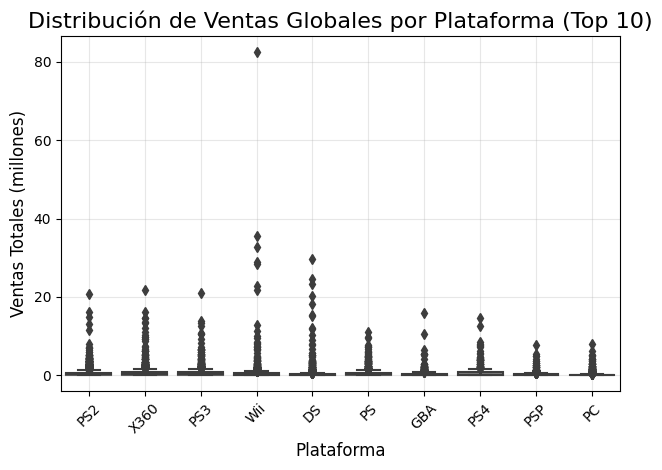

Estadísticas de ventas por plataforma:
          count  mean  median   std   min    max
platform                                        
PS2        2161  0.58    0.23  1.14  0.00  20.81
X360       1262  0.77    0.28  1.62  0.01  21.82
PS3        1331  0.71    0.27  1.39  0.00  21.05
Wii        1320  0.69    0.19  3.13  0.01  82.54
DS         2151  0.37    0.11  1.43  0.01  29.80
PS         1197  0.61    0.26  1.05  0.01  10.95
GBA         822  0.39    0.16  0.90  0.01  15.84
PS4         392  0.80    0.20  1.61  0.01  14.63
PSP        1209  0.24    0.09  0.52  0.01   7.68
PC          974  0.27    0.05  0.68  0.01   8.01


In [14]:
# Se crea el boxplot
sns.boxplot(data=df_top_platforms, x='platform', y='total_sales', 
            order=top_10_platforms_list['platform'])

plt.title('Distribución de Ventas Globales por Plataforma (Top 10)', fontsize=16)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Totales (millones)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Análisis estadístico complementario
print("Estadísticas de ventas por plataforma:")
print("="*50)

platform_stats = df_top_platforms.groupby('platform')['total_sales'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

# Ordenar por el orden de las top 10 plataformas
platform_stats = platform_stats.reindex(top_10_platforms_list['platform'])
print(platform_stats)

### Clonclusiones 3.3
- La mayoría de los juegos venden poco y unos pocos venden muchísimo (mercado desigual)
- PS4, Xbox 360 y PS3 tienen los mejores promedios de ventas por juego
- Wii tiene los mayores éxitos extremos
- PS2 y DS tienen los catálogos más grandes, pero ventas promedio más bajas que consolas más nuevas.
- Portátiles (DS, GBA, PSP) tienen ventas por juego significativamente más bajas. El mercado portátil es amplio, pero menos rentable por título.
- PC tiene ventas relativamente bajas y muy fragmentadas

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo obteniendo los *box-plot*. Estos muestran que la mayoría de los juegos tienen ventas bajas, hay valores extremos que dominan en cada plataforma. Esto muestra que el éxito de un juego no depende solo de la consola, sino también de su popularidad y estrategia de marketing.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Como sugerencia, cuando tengas gráficas *box-plot* con cajas muy "estrechas" debido a la presencia de numerosos datos atípicos, considera incluir una versión adicional usando escala logarítmica o ajustando el rango del eje Y. Esto facilitará la comparación y el análisis de los datos.

</div>
</div>

## 3.4 Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

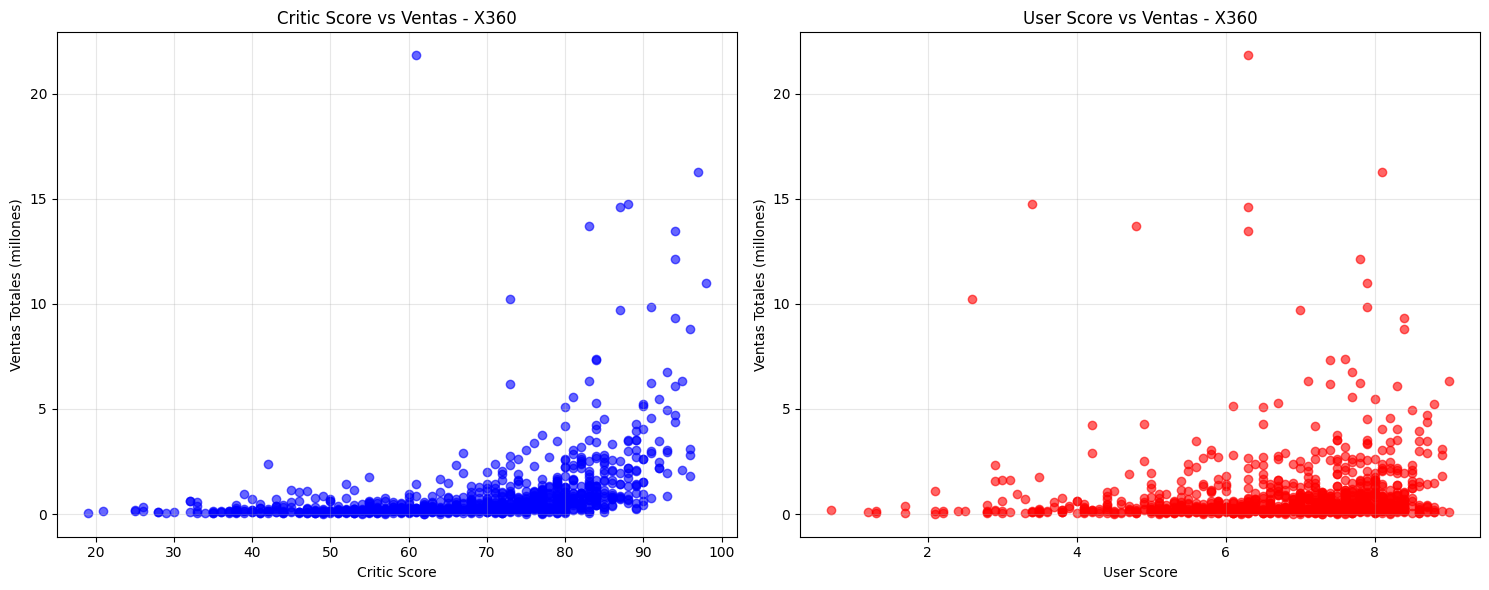

In [15]:
plataforma = 'X360'
#Se filtra por x360
df_games_X360 = df_games[df_games['platform']=='X360']

# Se crean subplots para ambas correlaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
ax1.scatter(df_games_X360['critic_score'], df_games_X360['total_sales'], 
           alpha=0.6, color='blue')
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Ventas Totales (millones)')
ax1.set_title(f'Critic Score vs Ventas - {plataforma}')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Ventas
ax2.scatter(df_games_X360['user_score'], df_games_X360['total_sales'], 
           alpha=0.6, color='red')
ax2.set_xlabel('User Score')
ax2.set_ylabel('Ventas Totales (millones)')
ax2.set_title(f'User Score vs Ventas - {plataforma}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones 3.4
- En general las reseñas SI afectan a las ventas en el caso del Xbox360
- La grafica de la reseña de los profesionales esta menos dispersa eso quiere decir que el efecto es casi directo, mientras mejor sea la calificacion, mas ventas tiene
- En el caso de la reseña de los usuarios la grafica es mas dispersa, eso quiere decir que influye un poco menos las reseñas en algunos juegos pero en general mientras mejor es la crítica mejores ventas tienen.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>


Genial, Con esta información se evidencia que la puntuación de los críticos está un poco más relacionada con las ventas que la de los usuarios, aunque la correlación es débil. En User_Score no hay una tendencia clara, pero en Critic_Score, los juegos mejor calificados tienden a vender más. Esto sugiere que las críticas especializadas pueden tener mayor impacto en las ventas.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Recuerda que para calcular numéricamente la correlación entre variables puedes usar el método `corr()` que estima por defecto la [correlación de Pearson](https://www.scribbr.com/statistics/pearson-correlation-coefficient/) entre dos variables

</div>

## 3.5 Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

Información básica:
Juegos únicos en X360: 1261
Juegos únicos en PS4: 392
Juegos que aparecen en ambas plataformas: 113

Total de registros de juegos comunes: 226

Top 10 juegos comunes (por ventas totales):
name
Grand Theft Auto V                28.89
Call of Duty: Black Ops 3         16.33
Call of Duty: Ghosts              14.07
Minecraft                         13.50
Call of Duty: Advanced Warfare    11.94
FIFA 16                           10.15
The Elder Scrolls V: Skyrim       10.11
FIFA 15                            9.00
FIFA 17                            7.98
Destiny                            7.56
Name: total_sales, dtype: float64




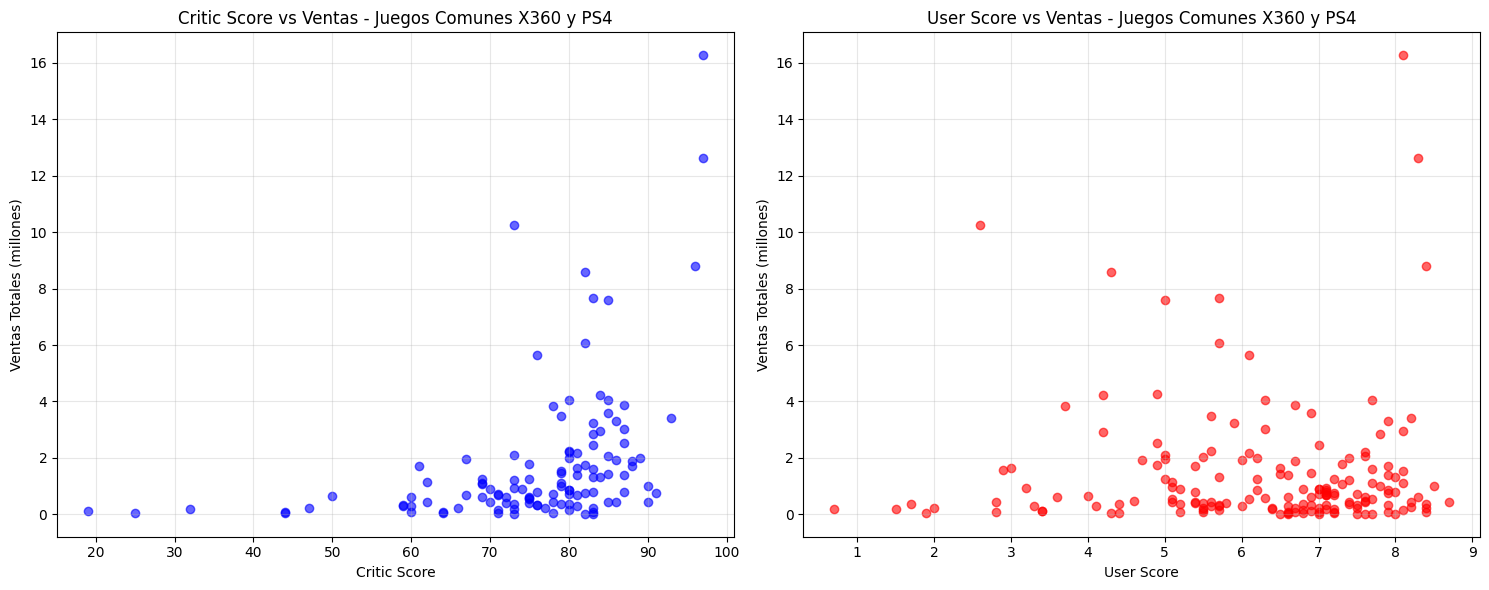

In [16]:
# Filtrar juegos de X360 y PS4
x360_games = df_games[df_games['platform'] == 'X360']['name'].unique()
ps4_games = df_games[df_games['platform'] == 'PS4']['name'].unique()

print("Información básica:")
print(f"Juegos únicos en X360: {len(x360_games)}")
print(f"Juegos únicos en PS4: {len(ps4_games)}")

# Encontrar juegos que están en ambas plataformas
common_games = set(x360_games) & set(ps4_games)
print(f"Juegos que aparecen en ambas plataformas: {len(common_games)}")

# Crear DataFrame con los juegos comunes
common_games_data = df_games[
    (df_games['name'].isin(common_games)) & 
    (df_games['platform'].isin(['X360', 'PS4']))
].copy()

print(f"\nTotal de registros de juegos comunes: {len(common_games_data)}")
# Análisis de los juegos comunes:
# Ver los juegos comunes ordenados por ventas totales
print("\nTop 10 juegos comunes (por ventas totales):")
print("="*50)

top_common = common_games_data.groupby('name')['total_sales'].sum().sort_values(ascending=False).head(10)
print(top_common)
print()
print()

####################################################################
# Crear subplots para ambas correlaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
ax1.scatter(common_games_data['critic_score'], common_games_data['total_sales'], 
           alpha=0.6, color='blue')
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Ventas Totales (millones)')
ax1.set_title('Critic Score vs Ventas - Juegos Comunes X360 y PS4')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Ventas
ax2.scatter(common_games_data['user_score'], common_games_data['total_sales'], 
           alpha=0.6, color='red')
ax2.set_xlabel('User Score')
ax2.set_ylabel('Ventas Totales (millones)')
ax2.set_title('User Score vs Ventas - Juegos Comunes X360 y PS4')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones 3.5
Se conservan las concluisones anteriores, esto es:
- En general las reseñas SI afectan a las ventas en el caso de los juegos en común con X360 y PS4
- La gráfica de la reseña de los profesionales esta menos dispersa eso quiere decir que el efecto es casi directo, mientras mejor sea la calificacion, más ventas tiene.
- En el caso de la reseña de los usuarios la grafica es más dispersa, eso quiere decir que influye un poco menos las reseñas en algunos juegos pero en general mientras mejor es la crítica mejores ventas tienen.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo analizando los juegos multiplataformas, con esta información es posible relacionar los juegos con mayor popularidad y las plataformas más comercializadas. 

</div>

## 3.6 Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [17]:

# Se crea un nuevo DataFrame agrupando el genero y el total de ventas
sales_per_genre = df_games.groupby(["genre"])["total_sales"].sum().reset_index().sort_values(by="total_sales", ascending=False).reset_index(drop=True)

# Se obtienen el top de mejores y peores ventas
top_5_sales_per_genre = sales_per_genre.head(5)
top_5_worts_sales_per_genre = sales_per_genre.tail(5)

# Se visualizan los resultados
print('Top 5 de generos mas rentables')
print(top_5_sales_per_genre)
print()
print('Top 5 de generos menos rentables')
print(top_5_worts_sales_per_genre)

Top 5 de generos mas rentables
          genre  total_sales
0        Action      1744.17
1        Sports      1331.27
2       Shooter      1052.45
3  Role-Playing       934.56
4      Platform       827.77

Top 5 de generos menos rentables
         genre  total_sales
7     Fighting       447.53
8   Simulation       389.97
9       Puzzle       242.57
10   Adventure       237.59
11    Strategy       174.23


### Conclusiones 3.6
El mercado de videojuegos está dominado por géneros de acción, deportes y disparos, que concentran la mayoría de las ventas mundiales.
Otros géneros como estrategia, aventura o puzzle, aunque importantes, representan nichos más pequeños y con menor impacto comercial.


# Paso 4. Crea un perfil de usuario para cada región

## 4.1 Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.

Las 5 plataformas principales de Norteamérica
  platform  na_sales
0     X360    602.47
1      PS2    583.84
2      Wii    496.90
3      PS3    393.49
4       DS    382.40

Las 5 plataformas principales de la Unión Europea
  platform  eu_sales
0      PS2    339.29
1      PS3    330.29
2     X360    270.76
3      Wii    262.21
4       PS    213.61

Las 5 plataformas principales de Japón
  platform  jp_sales
0       DS    175.57
1       PS    139.82
2      PS2    139.20
3     SNES    116.55
4      3DS    100.67



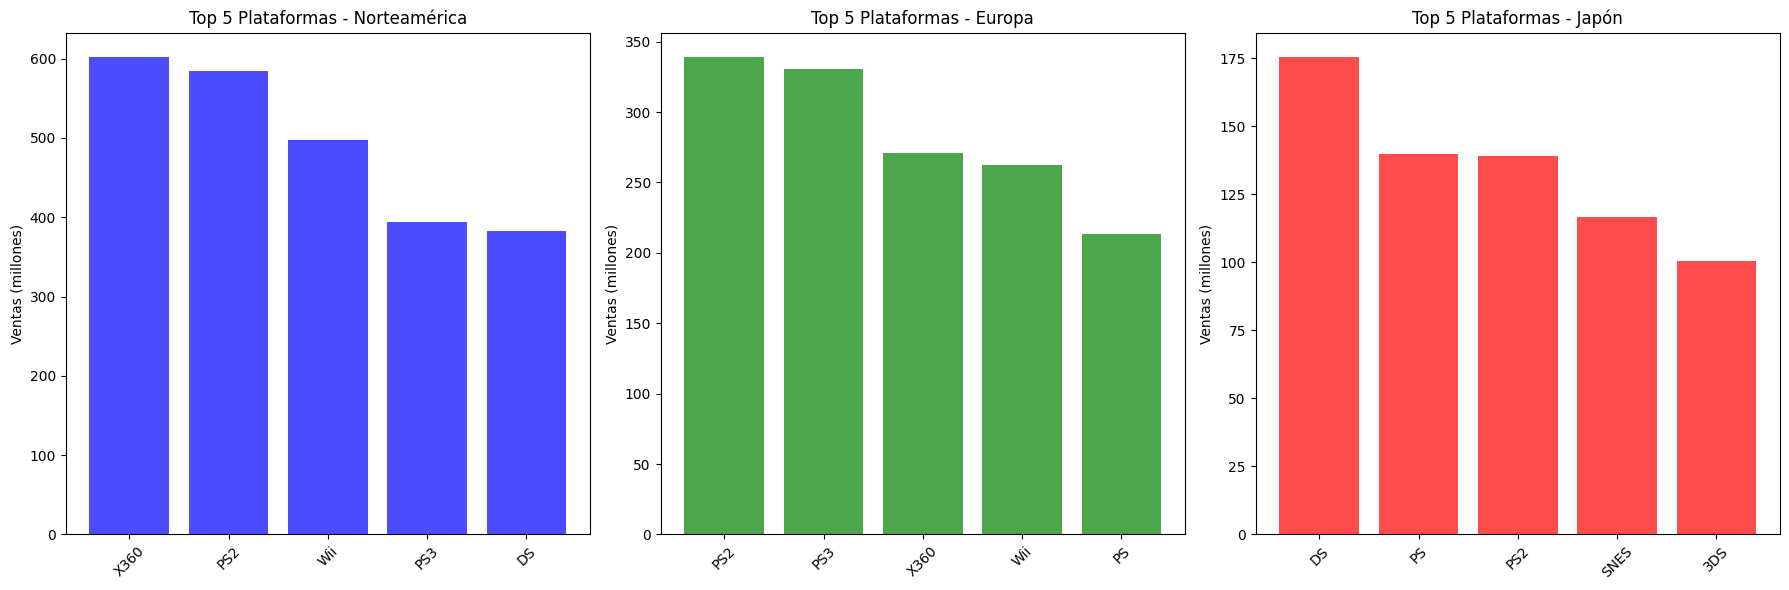

In [18]:
# Se crea un nuevo DataFrame agrupando la plataforma y las ventas de Norte America
df_games_na_platform = df_games.groupby(["platform"])["na_sales"].sum().reset_index().sort_values(by="na_sales", ascending=False).reset_index(drop=True)
top_5_games_na_platform = df_games_na_platform.head(5)
print("Las 5 plataformas principales de Norteamérica")
print(top_5_games_na_platform)
print()

# Se crea un nuevo DataFrame agrupando la plataforma y las ventas de la Union Europea
df_games_eu_platform = df_games.groupby(["platform"])["eu_sales"].sum().reset_index().sort_values(by="eu_sales", ascending=False).reset_index(drop=True)
top_5_games_eu_platform = df_games_eu_platform.head(5)
print("Las 5 plataformas principales de la Unión Europea")
print(top_5_games_eu_platform)
print()

# Se crea un nuevo DataFrame agrupando la plataforma y las ventas de Japón
df_games_jp_platform = df_games.groupby(["platform"])["jp_sales"].sum().reset_index().sort_values(by="jp_sales", ascending=False).reset_index(drop=True)
top_5_games_jp_platform = df_games_jp_platform.head(5)
print("Las 5 plataformas principales de Japón")
print(top_5_games_jp_platform)
print()

# Se crean los 3 gráficos comparativos
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico Norteamérica
ax1.bar(top_5_games_na_platform['platform'], top_5_games_na_platform['na_sales'], color='blue', alpha=0.7)
ax1.set_title('Top 5 Plataformas - Norteamérica')
ax1.set_ylabel('Ventas (millones)')
ax1.tick_params(axis='x', rotation=45)

# Gráfico Europa
ax2.bar(top_5_games_eu_platform['platform'], top_5_games_eu_platform['eu_sales'], color='green', alpha=0.7)
ax2.set_title('Top 5 Plataformas - Europa')
ax2.set_ylabel('Ventas (millones)')
ax2.tick_params(axis='x', rotation=45)

# Gráfico Japón
ax3.bar(top_5_games_jp_platform['platform'], top_5_games_jp_platform['jp_sales'], color='red', alpha=0.7)
ax3.set_title('Top 5 Plataformas - Japón')
ax3.set_ylabel('Ventas (millones)')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Conclusinones 4.1
1. Las preferencias de plataformas cambian significativamente por región
    - **Norteamérica** favorece principalmente consolas de Microsoft (Xbox 360) y Sony (PS2, PS3), pero también destaca la Wii.
    - **Europa** es una región dominada por Sony (PS2 y PS3 como las más vendidas).
    - **Japón** muestra una fuerte preferencia por consolas portátiles y de Nintendo (DS, SNES, 3DS).
2.  Norteamérica es el único mercado donde Microsoft domina
    - Xbox 360 es líder en NA, con 602.47 millones de ventas.
    - En Europa baja al tercer lugar.
    - En Japón prácticamente no aparece entre los primeros lugares.
3.  Sony es la marca más consistente a nivel global
    - PS2 (top 5 en todas las regiones)
    - PS3 (top 5 en NA y UE)
    - PS original (top 5 en UE y JP)
4.  Japón tiene un comportamiento muy diferente al de Occidente. El mercado japonés es tradicionalmente más fuerte en consolas portátiles y plataformas propias de Nintendo.
Mientras NA y UE se concentran en consolas de sobremesa, Japón prefiere:
    - DS (primer lugar)
    - SNES
    - 3DS

## 4.2 Los cinco géneros principales. Explica la diferencia.

Los 5 generos principales de Norteamérica
      genre  na_sales
0    Action    879.01
1    Sports    684.43
2   Shooter    592.24
3  Platform    445.50
4      Misc    407.27

Los 5 generos principales de la Unión Europea
     genre  eu_sales
0   Action    519.13
1   Sports    376.79
2  Shooter    317.34
3   Racing    236.51
4     Misc    212.74

Los 5 generos principales de Japón
          genre  jp_sales
0  Role-Playing    355.41
1        Action    161.43
2        Sports    135.54
3      Platform    130.83
4          Misc    108.11



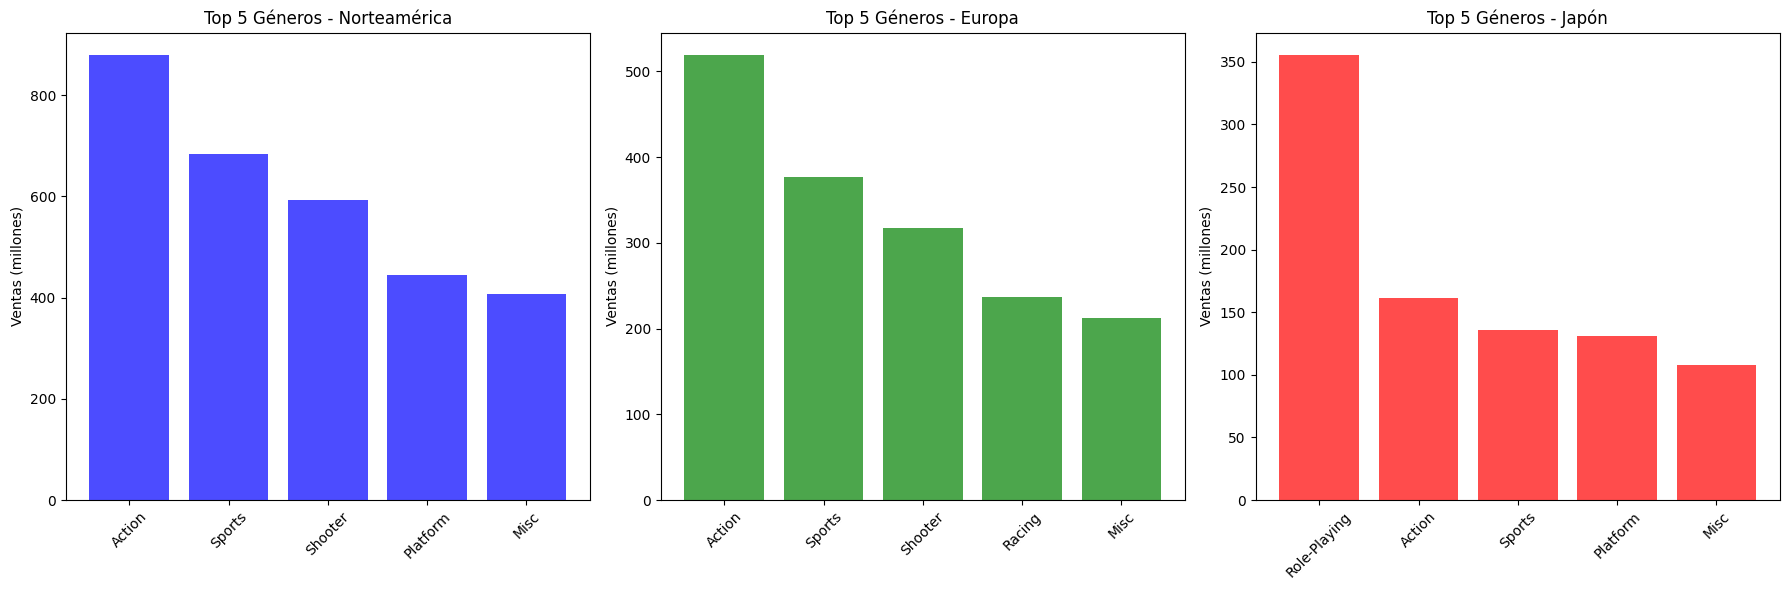

In [19]:
# Se crea un nuevo DataFrame agrupando el genero y las ventas de Norteamérica
df_games_na_genre = df_games.groupby(["genre"])["na_sales"].sum().reset_index().sort_values(by="na_sales", ascending=False).reset_index(drop=True)
top_5_games_na_genre = df_games_na_genre.head(5)
print("Los 5 generos principales de Norteamérica")
print(top_5_games_na_genre)
print()

# Se crea un nuevo DataFrame agrupando el genero y las ventas de la Unión Europea
df_games_eu_genre = df_games.groupby(["genre"])["eu_sales"].sum().reset_index().sort_values(by="eu_sales", ascending=False).reset_index(drop=True)
top_5_games_eu_genre = df_games_eu_genre.head(5)
print("Los 5 generos principales de la Unión Europea")
print(top_5_games_eu_genre)
print()

# Se crea un nuevo DataFrame agrupando el genero y las ventas de Japón
df_games_jp_genre = df_games.groupby(["genre"])["jp_sales"].sum().reset_index().sort_values(by="jp_sales", ascending=False).reset_index(drop=True)
top_5_games_jp_genre = df_games_jp_genre.head(5)
print("Los 5 generos principales de Japón")
print(top_5_games_jp_genre)
print()

# Se crean los 3 gráficos comparativos
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico Norteamérica
ax1.bar(top_5_games_na_genre['genre'], top_5_games_na_genre['na_sales'], color='blue', alpha=0.7)
ax1.set_title('Top 5 Géneros - Norteamérica')
ax1.set_ylabel('Ventas (millones)')
ax1.tick_params(axis='x', rotation=45)

# Gráfico Europa
ax2.bar(top_5_games_eu_genre['genre'], top_5_games_eu_genre['eu_sales'], color='green', alpha=0.7)
ax2.set_title('Top 5 Géneros - Europa')
ax2.set_ylabel('Ventas (millones)')
ax2.tick_params(axis='x', rotation=45)

# Gráfico Japón
ax3.bar(top_5_games_jp_genre['genre'], top_5_games_jp_genre['jp_sales'], color='red', alpha=0.7)
ax3.set_title('Top 5 Géneros - Japón')
ax3.set_ylabel('Ventas (millones)')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Conclusiones 4.2
1. Occidente (NA y EU) es muy similar en gustos:
   - Action, Sports y Shooter son los géneros dominantes.
   - Competitividad, dinamismo y acción rápida influyen en la demanda.
2. Japón es un mercado único y muy diferenciado:
   - Los RPG son el género líder.
   - Acción y deportes son secundarios.
3. El género Platform mantiene cierta universalidad, especialmente por la presencia global de Nintendo.
4. El género Misc tiene una demanda estable en las tres regiones, aunque menor comparado con géneros líderes.


## 4.3 Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

Ventas por clasificación ESRB:
        NA_ventas  EU_ventas  JP_ventas  Total_ventas  Cantidad_juegos
rating                                                                
E         1292.99     710.25     198.11       2435.52             3990
T          759.75     427.03     151.40       1493.35             2961
M          748.48     483.97      64.24       1473.79             1563
E10+       353.32     188.52      40.20        655.60             1420
K-A          2.56       0.27       1.46          4.32                3
AO           1.26       0.61       0.00          1.96                1
EC           1.53       0.11       0.00          1.75                8
RP           0.00       0.08       0.00          0.09                3



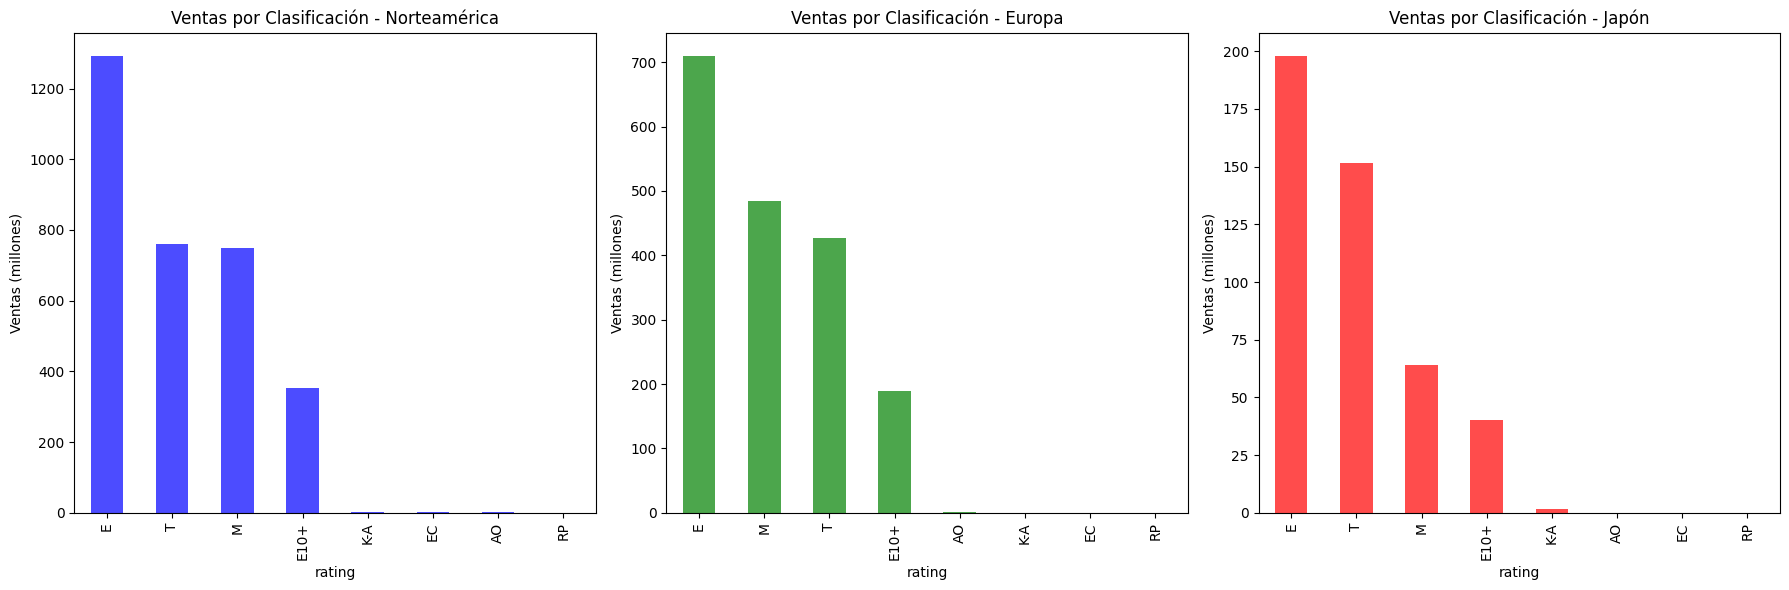

In [20]:
# Primero, se averigua qué clasificaciones hay
#print("Clasificaciones ESRB disponibles:")
#print(df_games['rating'].value_counts())
#print(f"\nJuegos sin clasificación: {df_games['rating'].isnull().sum()}")

# Se filtra solo juegos con clasificación para el análisis
df_games_rated = df_games[df_games['rating'].notna()].copy()
#print(f"Juegos con clasificación: {len(df_games_rated)}")
#print()


# Se agrupa ventas por clasificación y región
rating_analysis = df_games_rated.groupby('rating').agg({
    'na_sales': 'sum',
    'eu_sales': 'sum', 
    'jp_sales': 'sum',
    'total_sales': 'sum',
    'name': 'count'  # Cantidad de juegos
}).round(2)

rating_analysis.columns = ['NA_ventas', 'EU_ventas', 'JP_ventas', 'Total_ventas', 'Cantidad_juegos']
print("Ventas por clasificación ESRB:")
print(rating_analysis.sort_values('Total_ventas', ascending=False))
print()

# Crear gráfico de barras por región
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Norteamérica
rating_analysis.sort_values('NA_ventas', ascending=False)['NA_ventas'].plot(kind='bar', ax=ax1, color='blue', alpha=0.7)
ax1.set_title('Ventas por Clasificación - Norteamérica')
ax1.set_ylabel('Ventas (millones)')

# Europa
rating_analysis.sort_values('EU_ventas', ascending=False)['EU_ventas'].plot(kind='bar', ax=ax2, color='green', alpha=0.7)
ax2.set_title('Ventas por Clasificación - Europa')
ax2.set_ylabel('Ventas (millones)')

# Japón
rating_analysis.sort_values('JP_ventas', ascending=False)['JP_ventas'].plot(kind='bar', ax=ax3, color='red', alpha=0.7)
ax3.set_title('Ventas por Clasificación - Japón')
ax3.set_ylabel('Ventas (millones)')

plt.tight_layout()
plt.show()

### Conclusiones 4.3
1. Los juegos E son los reyes del mercado global.
    - Amplio público, muchas franquicias exitosas, gran catálogo.
2. En Norteamérica y Europa, los juegos T y M tienen ventas muy fuertes, reflejando un mercado más orientado a juegos de acción, disparos, deportes y aventuras maduras.
3. En Japón, la clasificación ESRB no influye tanto, por eso sus ventas por rating no siguen el patrón occidental.
4. Las ventas disminuyen conforme la clasificación es más restrictiva, reduciendo la audiencia objetivo.
5. Clasificaciones extremas (AO, EC) no son relevantes comercialmente.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Diego has logrado identificar claramente las diferencias entre América del Norte, Europa y Japón, no solo en términos de plataformas y géneros predominantes, sino también en la influencia de las clasificaciones ESRB, lo que refleja tu capacidad para conectar datos con tendencias culturales y de comportamiento. 


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Para lograr un análisis comparativo más efectivo, sería beneficioso presentar cada sección de información empleando un único diagrama de barras. Al asignar un color distintivo a cada región, podremos crear una representación visual unificada que facilite la identificación de patrones y diferencias entre las distintas áreas. Esta consolidación de datos no solo optimizará el espacio visual, sino que también permitirá al lector establecer conexiones y comparaciones de manera más intuitiva y directa entre los distintos conjuntos de información. Acá te muestro un ejemplo 

<img src="https://www.analyticslane.com/storage/2022/06/matplotlib-barras-adyacentes.png.webp" width="400">

En el siguiente enlace se explica cómo se puede construir: [Gráficos de Barras](https://www.analyticslane.com/2022/07/05/graficos-de-barras-en-matplotlib/)

</div>
</div>

# Paso 5. Prueba las siguientes hipótesis:

## 5.1 Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [21]:
# Creamos un Series de user_score pertenecientes a juegos de Xbox One
df_games_xone = df_games[df_games['platform']=='XOne']
df_games_xone_user_score = df_games_xone['user_score'].reset_index(drop=True)
xone_mean = round(df_games_xone_user_score.mean(), 2)
xone_median = round(df_games_xone_user_score.median(), 2)

# Reemplazar NaN por la media
df_games_xone_user_score_filled = df_games_xone_user_score.fillna(xone_mean)

# Imprimir resultados
#print(df_games_xone_user_score_filled)
print(f'La media del user score del Xbox One es: {xone_mean}')
print(f'La mediana del user score del Xbox One es: {xone_median}')

# Creamos un Series de user_score pertenecientes a juegos de PC
df_games_pc = df_games[df_games['platform']=='PC']
df_games_pc_user_score = df_games_pc['user_score'].reset_index(drop=True)
pc_mean = round(df_games_pc_user_score.mean(), 2)
pc_median = round(df_games_pc_user_score.median(), 2)

# Reemplazar NaN por la media
df_games_pc_user_score_filled = df_games_pc_user_score.fillna(pc_mean)

# Imprimir resultados
# print(df_games_pc_user_score_filled)
print(f'La media del user score de la PC es: {pc_mean}')
print(f'La mediana del user score de la PC es: {pc_median}')

#Prueba de Hipotesis
alpha = .05 #

results = st.ttest_ind(df_games_xone_user_score_filled, df_games_pc_user_score_filled) # prueba la hipótesis de que las medias de las dos poblaciones independientes son iguales

print('valor p:', results.pvalue) #imprime el valor p obtenido)

if (results.pvalue < alpha): # compara los valores p obtenidos con el nivel de significación estadística):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")



La media del user score del Xbox One es: 6.52
La mediana del user score del Xbox One es: 6.8
La media del user score de la PC es: 7.06
La mediana del user score de la PC es: 7.5
valor p: 1.3136034438781066e-08
Rechazamos la hipótesis nula


### Conclusiones 5.1
- La hipótesis nula es que las medias de las calificaciones de usuario de ambas plataformas son iguales.
- La hipótesis alternativa es que son diferentes.
- Se ha seleccionado el tipo de hipótesis st.ttest_ind ya que son Series independientes entre si.
- Se rechaza la hipótesis nula ya que la probabilidad de que sean iguales es muy baja
- Los análisis estadísticos muestran que los juegos de PC obtienen calificaciones de usuario significativamente más altas que los juegos de Xbox One.

## 5.2 Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [22]:
# Creamos un Series de user_score pertenecientes a genero Action
df_games_action = df_games[df_games['genre']=='Action']
df_games_action_user_score = df_games_action['user_score'].reset_index(drop=True)
action_mean = round(df_games_action_user_score.mean(), 2)
action_median = round(df_games_action_user_score.median(), 2)

# Reemplazar NaN por la media
df_games_action_user_score_filled = df_games_action_user_score.fillna(action_mean)

# Imprimir resultados
#print(df_games_action_user_score_filled)
print(f'La media del user score del género Action es: {action_mean}')
print(f'La mediana del user score del género Action es: {action_median}')

# Creamos un Series de user_score pertenecientes a genero Sports
df_games_sports = df_games[df_games['genre']=='Sports']
df_games_sports_user_score = df_games_sports['user_score'].reset_index(drop=True)
sports_mean = round(df_games_sports_user_score.mean(), 2)
sports_median = round(df_games_sports_user_score.median(), 2)

# Reemplazar NaN por la media
df_games_sports_user_score_filled = df_games_sports_user_score.fillna(sports_mean)

# Imprimir resultados
#print(df_games_sports_user_score_filled)
print(f'La media del user score del género Sports es: {sports_mean}')
print(f'La mediana del user score del género Sports es: {sports_median}')

#Prueba de Hipotesis
alpha = .05 

results = st.ttest_ind(df_games_action_user_score_filled, df_games_sports_user_score_filled) # prueba la hipótesis de que las medias de las dos poblaciones independientes son iguales

print('valor p:', results.pvalue) #imprime el valor p obtenido)

if (results.pvalue < alpha): # compara los valores p obtenidos con el nivel de significación estadística):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


La media del user score del género Action es: 7.05
La mediana del user score del género Action es: 7.4
La media del user score del género Sports es: 6.96
La mediana del user score del género Sports es: 7.4
valor p: 0.0014946337613581133
Rechazamos la hipótesis nula


### Conclusiones 5.2
- La hipótesis nula es que las medias de las calificaciones de usuario de ambos géneros son iguales.
- La hipótesis alternativa es que son diferentes.
- Se ha seleccionado el tipo de hipótesis st.ttest_ind ya que son Series independientes entre si.
- Se rechaza la hipótesis nula ya que la probabilidad de que sean iguales es muy baja.
- La media sugiere que, en general, los juegos de Action son un poco mejor valorados por los usuarios que los juegos de Sports.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Has realizado un análisis muy completo al comparar los `user_score` de distintas plataformas y géneros mediante estadísticas descriptivas y pruebas de hipótesis, demostrando un buen dominio del proceso analítico. Es positivo que hayas manejado los valores faltantes antes de aplicar la prueba t. 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Como recomendación, sería ideal utilizar la opción `nan_policy='omit'` dentro de `st.ttest_ind` en lugar de rellenar con la media, ya que este enfoque conserva mejor la naturaleza de los datos originales.


</div>
</div>




</div>

# Conclusiones Generales
El análisis revela que la industria del videojuego está influenciada por factores combinados: evolución histórica, vida útil de plataformas, géneros predominantes, diferencias culturales entre regiones y percepciones del público. Los géneros Action, Sports y Shooter dominan el mercado occidental, mientras que Japón mantiene preferencias únicas. Las reseñas profesionales tienen un impacto directo en las ventas, y los análisis estadísticos confirman diferencias reales entre plataformas y géneros. En conjunto, estos hallazgos permiten comprender mejor el comportamiento del mercado global y sirven como base para estrategias comerciales y análisis futuros.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Tu conclusión general sintetiza de manera clara y equilibrada los distintos factores que configuran el comportamiento de la industria del videojuego, integrando elementos históricos, culturales y estadísticos.

</div>